# Baseline Fraud Detection Models — ULB Credit Card Fraud Dataset

Train and compare naive and imbalance-aware baselines on a **temporal** train/test split. The test set is held out and never used for tuning — it will carry forward into threshold optimization.

In [8]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
TRAIN_FRACTION = 0.70
DATA_PATH = Path("../data/creditcard.csv")

## 1. Load data and temporal train/test split

In [9]:
# Load and sort chronologically — random splits would leak future transactions into training
df = pd.read_csv(DATA_PATH).sort_values("Time").reset_index(drop=True)

split_idx = int(len(df) * TRAIN_FRACTION)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

feature_cols = [c for c in df.columns if c != "Class"]
X_train, y_train = train_df[feature_cols], train_df["Class"]
X_test, y_test = test_df[feature_cols], test_df["Class"]

print(f"Total rows: {len(df):,}")
print(f"Train: {len(train_df):,} rows ({TRAIN_FRACTION:.0%} of timeline)")
print(f"Test:  {len(test_df):,} rows ({1 - TRAIN_FRACTION:.0%} of timeline)\n")

# Confirm both splits contain enough fraud examples for evaluation
for name, labels in [("Train", y_train), ("Test", y_test)]:
    n_fraud = int(labels.sum())
    rate = labels.mean() * 100
    print(f"{name:5s} — fraud count: {n_fraud:>4d}  |  fraud rate: {rate:.4f}%")

Total rows: 284,807
Train: 199,364 rows (70% of timeline)
Test:  85,443 rows (30% of timeline)

Train — fraud count:  384  |  fraud rate: 0.1926%
Test  — fraud count:  108  |  fraud rate: 0.1264%


## 2. Naive baseline — Logistic Regression (no class weighting, no resampling)

In [10]:
# "Plain" baseline: imbalanced labels left as-is, no SMOTE/undersampling, no class_weight.
# StandardScaler is included only for LR numerical stability — it does not address imbalance.
lr_naive = Pipeline([
    ("scaler", StandardScaler()),
    (
        "clf",
        LogisticRegression(
            max_iter=1_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

lr_naive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 3. Evaluate naive baseline on held-out test set

=== Logistic Regression (naive) ===

Confusion matrix (rows=actual, cols=predicted):
              Pred 0    Pred 1
  Actual 0    85,319       16
  Actual 1        55       53

Fraud class (1) — Precision: 0.7681
Fraud class (1) — Recall:    0.4907
Fraud class (1) — F1:        0.5989

Overall accuracy: 0.9992  ← misleading given ~0.17% fraud rate
Average precision (PR-AUC): 0.7054


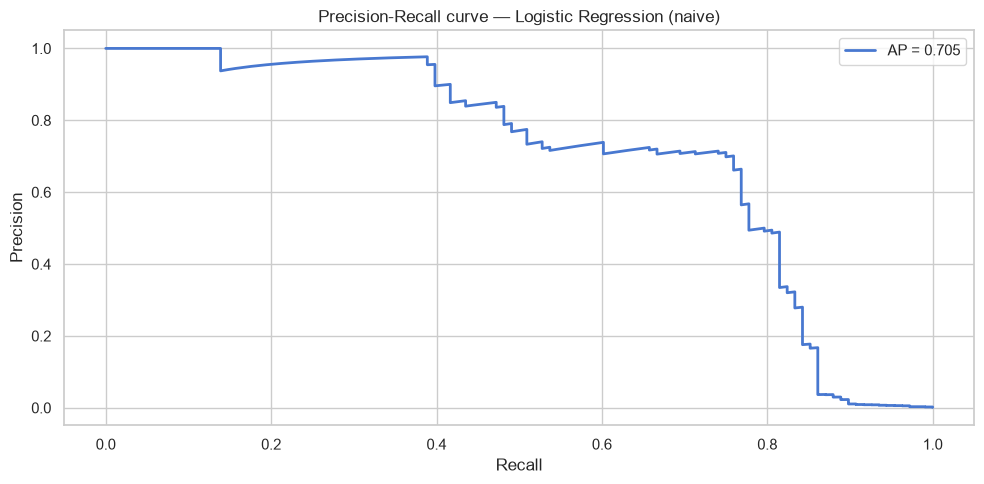

In [11]:
def evaluate_model(model, X_test, y_test, model_name: str, plot_pr: bool = True):
    """Evaluate a fitted classifier on the test set.

    Returns a dict of metrics and optionally plots the precision-recall curve.
    Focus is on fraud class (Class == 1), not overall accuracy.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix: rows = actual, cols = predicted
    cm = confusion_matrix(y_test, y_pred)
    print(f"=== {model_name} ===\n")
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(f"              Pred 0    Pred 1")
    print(f"  Actual 0   {cm[0, 0]:>7,}  {cm[0, 1]:>7,}")
    print(f"  Actual 1   {cm[1, 0]:>7,}  {cm[1, 1]:>7,}\n")

    # Metrics for the fraud class specifically (pos_label=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1], average=None, zero_division=0
    )
    fraud_precision, fraud_recall, fraud_f1 = precision[0], recall[0], f1[0]

    print(f"Fraud class (1) — Precision: {fraud_precision:.4f}")
    print(f"Fraud class (1) — Recall:    {fraud_recall:.4f}")
    print(f"Fraud class (1) — F1:        {fraud_f1:.4f}")

    # Overall accuracy is shown but flagged — ~99.9% is misleading when fraud is <0.2%
    acc = accuracy_score(y_test, y_pred)
    print(f"\nOverall accuracy: {acc:.4f}  ← misleading given ~0.17% fraud rate")

    avg_precision = average_precision_score(y_test, y_prob)
    print(f"Average precision (PR-AUC): {avg_precision:.4f}")

    if plot_pr:
        prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
        fig, ax = plt.subplots()
        ax.plot(rec_curve, prec_curve, linewidth=2, label=f"AP = {avg_precision:.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"Precision-Recall curve — {model_name}")
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "fraud_precision": fraud_precision,
        "fraud_recall": fraud_recall,
        "fraud_f1": fraud_f1,
        "accuracy": acc,
        "avg_precision": avg_precision,
    }


metrics_naive = evaluate_model(lr_naive, X_test, y_test, "Logistic Regression (naive)")

### What went wrong with the naive baseline?

The naive logistic regression looks successful on paper — overall accuracy is ~99.9% — but that number is almost meaningless here. With fraud making up only ~0.13% of the test set, a model that predicts "not fraud" for every transaction would still score ~99.87% accuracy.

**Recall on the fraud class is the real failure mode.** At the default 0.5 probability threshold, the model catches only about half of fraud cases (~49% recall), leaving the majority of fraudulent transactions undetected. In a fraud system, those missed cases are the costly ones.

**Why this happens:**
- The training set is ~578:1 legitimate-to-fraud. Without `class_weight` or resampling, logistic regression minimizes overall log-loss by favouring the majority class.
- The default decision threshold (0.5) assumes equal misclassification costs. For fraud detection, a false negative (missed fraud) is far more expensive than a false positive (flagged legitimate transaction).
- High precision (~77%) with low recall means the model is conservative: when it does flag fraud, it is often right, but it rarely flags anything at all.

This is a deliberate baseline failure — it motivates imbalance-aware training and, later, threshold tuning on a validation set (not this test set).

## 4. Logistic Regression with `class_weight='balanced'`

=== Logistic Regression (balanced) ===

Confusion matrix (rows=actual, cols=predicted):
              Pred 0    Pred 1
  Actual 0    83,695    1,640
  Actual 1        13       95

Fraud class (1) — Precision: 0.0548
Fraud class (1) — Recall:    0.8796
Fraud class (1) — F1:        0.1031

Overall accuracy: 0.9807  ← misleading given ~0.17% fraud rate
Average precision (PR-AUC): 0.7677


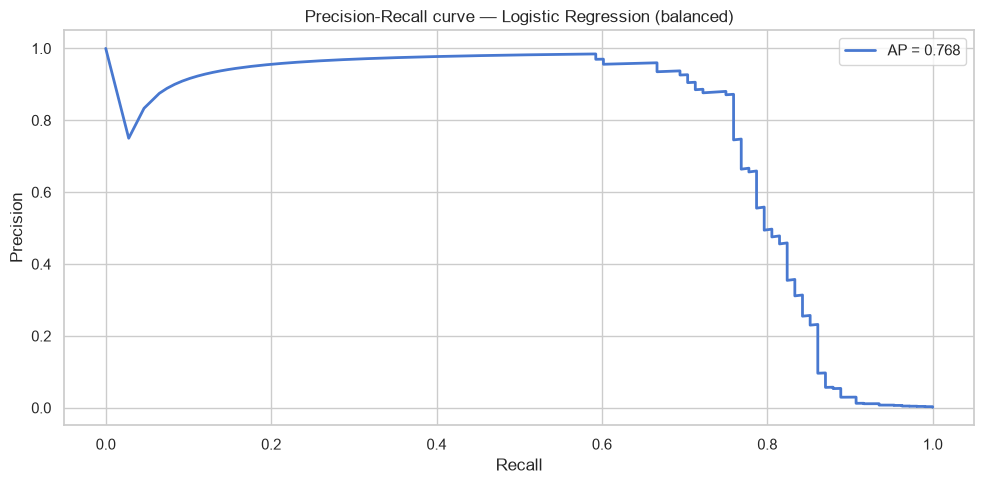

In [12]:
lr_balanced = Pipeline([
    ("scaler", StandardScaler()),
    (
        "clf",
        LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",  # inversely weights classes by frequency
            random_state=RANDOM_STATE,
        ),
    ),
])

lr_balanced.fit(X_train, y_train)
metrics_balanced = evaluate_model(lr_balanced, X_test, y_test, "Logistic Regression (balanced)")

## 5. XGBoost with `scale_pos_weight`

Training class ratio (legit:fraud) ≈ 518.2:1
scale_pos_weight = 518.18

=== XGBoost (scale_pos_weight) ===

Confusion matrix (rows=actual, cols=predicted):
              Pred 0    Pred 1
  Actual 0    85,326        9
  Actual 1        28       80

Fraud class (1) — Precision: 0.8989
Fraud class (1) — Recall:    0.7407
Fraud class (1) — F1:        0.8122

Overall accuracy: 0.9996  ← misleading given ~0.17% fraud rate
Average precision (PR-AUC): 0.7988


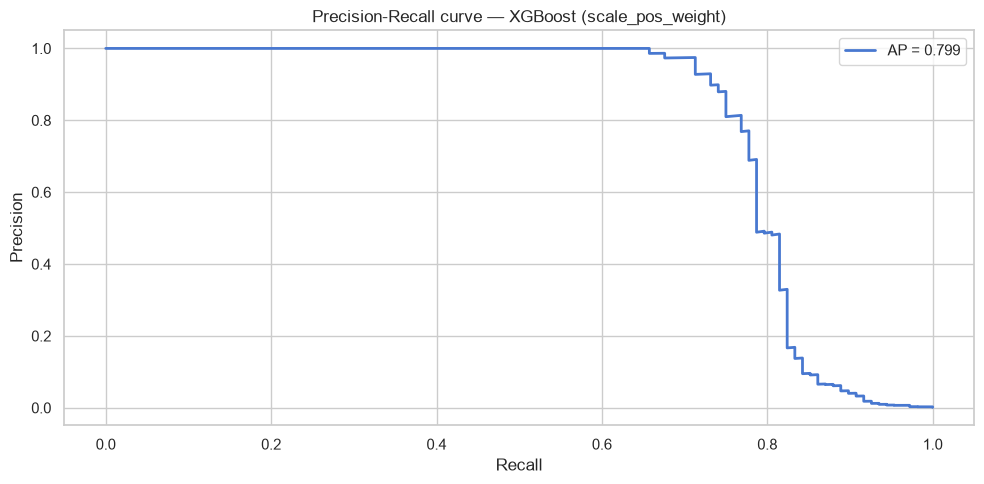

In [13]:
# scale_pos_weight = count(negative) / count(positive) in training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Training class ratio (legit:fraud) ≈ {scale_pos_weight:.1f}:1")
print(f"scale_pos_weight = {scale_pos_weight:.2f}\n")

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    verbosity=0,
)

xgb_model.fit(X_train, y_train)
metrics_xgb = evaluate_model(xgb_model, X_test, y_test, "XGBoost (scale_pos_weight)")

## 6. Side-by-side comparison

Test-set metrics — all models evaluated on the same held-out 30% temporal split



,Fraud Precision,Fraud Recall,Fraud F1,PR-AUC (avg precision),Accuracy (misleading)
model,,,,,
Logistic Regression (naive),0.7681,0.4907,0.5989,0.7054,0.9992
Logistic Regression (balanced),0.0548,0.8796,0.1031,0.7677,0.9807
XGBoost (scale_pos_weight),0.8989,0.7407,0.8122,0.7988,0.9996


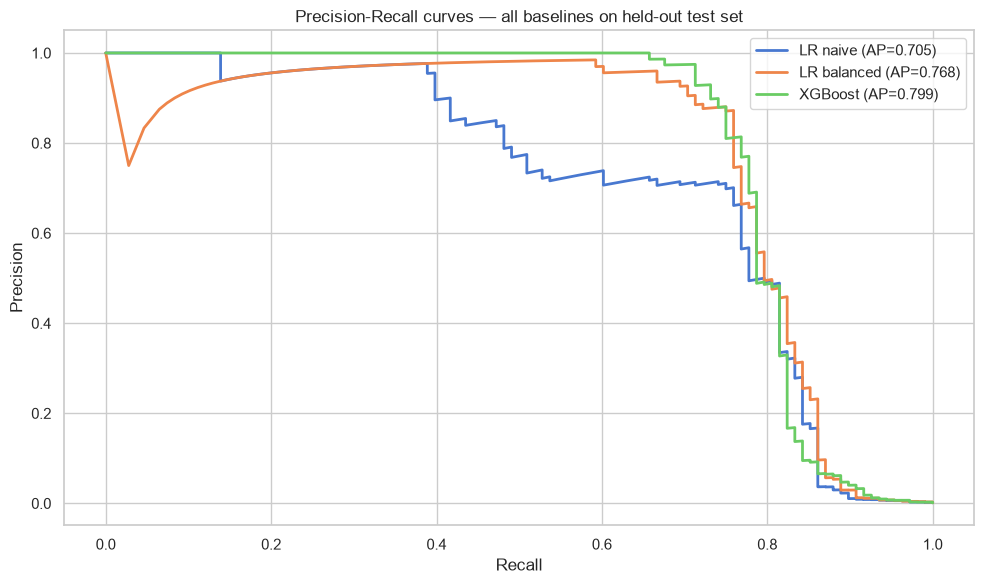

In [14]:
comparison = pd.DataFrame([metrics_naive, metrics_balanced, metrics_xgb]).set_index("model")

# Reorder columns for readability; round for display
comparison = comparison[[
    "fraud_precision", "fraud_recall", "fraud_f1", "avg_precision", "accuracy"
]].round(4)
comparison.columns = [
    "Fraud Precision",
    "Fraud Recall",
    "Fraud F1",
    "PR-AUC (avg precision)",
    "Accuracy (misleading)",
]

print("Test-set metrics — all models evaluated on the same held-out 30% temporal split\n")
display(comparison)

# Overlay PR curves for direct visual comparison
fig, ax = plt.subplots(figsize=(10, 6))
models_to_plot = [
    (lr_naive, "LR naive"),
    (lr_balanced, "LR balanced"),
    (xgb_model, "XGBoost"),
]
for model, label in models_to_plot:
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, linewidth=2, label=f"{label} (AP={ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — all baselines on held-out test set")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Takeaways and next step

**Best precision-recall trade-off:** XGBoost with `scale_pos_weight` delivers the strongest overall performance on this held-out test set — highest PR-AUC (~0.80), fraud F1 (~0.81), and recall (~0.74) while maintaining high precision (~0.90). It dominates the naive logistic regression on every fraud-relevant metric.

**Balanced logistic regression** recovers recall (~0.88) but at a steep precision cost (~0.05) — it floods analysts with false positives. That may be acceptable depending on review capacity, but it is a worse precision-recall trade-off than XGBoost at the default 0.5 threshold.

**Important:** None of these models were tuned on the test set. Hyperparameters are defaults (or simple imbalance corrections). The test set remains clean and held out.

**Next step:** Take the best candidate (XGBoost) into **threshold optimization** on a validation split carved from the training timeline — adjusting the decision threshold to hit a target recall or false-positive rate without touching this test set.